In [2]:
#!pip install tensorflow opencv-python matplotlib

In [13]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/Dataset"

In [36]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.7,1.3]
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    dataset_path + "/Train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    dataset_path + "/Validation",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

Found 1400 images belonging to 2 classes.
Found 300 images belonging to 2 classes.


In [37]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [38]:
for layer in base_model.layers:
    layer.trainable = False

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2


model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    BatchNormalization(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),

    Dense(1, activation='sigmoid')
])

In [41]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 397ms/step - accuracy: 0.6186 - loss: 1.0706 - val_accuracy: 0.6767 - val_loss: 0.8494
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 359ms/step - accuracy: 0.7286 - loss: 0.8391 - val_accuracy: 0.7367 - val_loss: 0.8207
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 361ms/step - accuracy: 0.7714 - loss: 0.7482 - val_accuracy: 0.7300 - val_loss: 0.8162
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 365ms/step - accuracy: 0.7900 - loss: 0.7243 - val_accuracy: 0.7300 - val_loss: 0.8145
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 365ms/step - accuracy: 0.8307 - loss: 0.6154 - val_accuracy: 0.7267 - val_loss: 0.8131


In [43]:
# Unfreeze ONLY last 10 layers (not 30)
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Recompile with VERY low LR
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train VERY little
model.fit(
    train_data,
    validation_data=val_data,
    epochs=2
)

Epoch 1/2
88/88 ━━━━━━━━━━━━━━━━━━━━ 46s 431ms/step - accuracy: 0.7800 - loss: 0.7312 - val_accuracy: 0.7067 - val_loss: 0.8842
Epoch 2/2
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 394ms/step - accuracy: 0.8150 - loss: 0.6668 - val_accuracy: 0.7133 - val_loss: 0.9809


In [62]:
model.save("/content/drive/MyDrive/deepfake_model.keras")

In [54]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Load image
    img = image.load_img(img_path, target_size=(128,128))

    # Preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array)[0][0]

    # Label
    label = "Real" if pred > 0.5 else "Fake"

    # Show image
    plt.imshow(img)
    plt.title(f"{label} (Prob: {pred:.2f})")
    plt.axis("off")
    plt.show()

    # Print result
    print("Prediction:", label)
    print("Probability:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


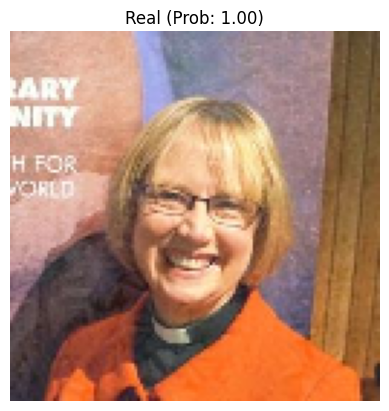

Prediction: Real
Probability: 0.99622416


In [60]:
predict_image("/content/drive/MyDrive/Dataset/Test/Real/real_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


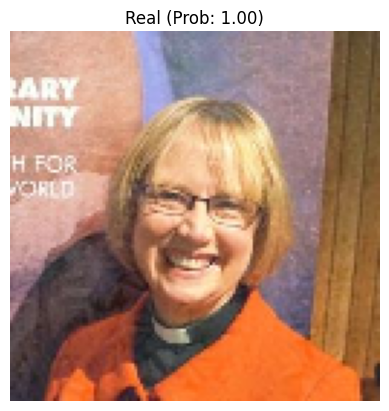

Prediction: Real
Probability: 0.99622416
None


In [61]:
result = predict_image("/content/drive/MyDrive/Dataset/Test/Real/real_1.jpg")
print(result)